In [13]:
#1 Day-1 Study Case "Early Warning System for Sustainable Education"
import pandas as pd
import numpy as np

# Mengatur seed agar data yang dihasilkan konsisten
np.random.seed(42)

# Menentukan jumlah baris
n_rows = 100

# Membuat data dummy
data = {
  'Student_ID': [f'STU_{i:03d}' for i in range(1, n_rows + 1)],
  'Gender': np.random.choice ([0, 1], n_rows),
  'Parental_Support': np.random.randint(1, 6, n_rows),
  'GPA_Sem1': np.round(np.random.uniform (2.0, 4.0, n_rows), 2),
  'GPA_Sem2': np.round(np.random.uniform (1.8, 4.0, n_rows), 2),
  'Attendance_Rate': np.random.randint(60, 101, n_rows),
  'Financial_Stress': np.random.randint(1, 6, n_rows),
}

# Membuat logika sederhana untuk kolom Target (Dropout/Graduate)
# Misal: Jika GPA rendah dan kehadiran rendah, kemungkinan Dropout (0) lebih tinggi
df = pd.DataFrame (data)

def determine_target(row):
  score = (row['GPA_Sem1'] * 0.3) + (row['GPA_Sem2'] * 0.3) + (row['Attendance_Rate'])
  if score < 2.5 or row['GPA_Sem2'] < 2.0:
    return 0 # Dropout
  else:
    return 1 # Graduate

df['Target'] = df.apply(determine_target, axis=1)

#Menyimpan ke file CSV
df.to_csv('student_data (not used).csv', index=False)

Hasil dari pembuatan data dummy diatas tidak dipakai, melainkan pakai student_data.csv di drive biar hasil visualisasinya sesuai dengan pdf

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

#1. Load Data (Karakteristik: Variety & Volume)
# Diasumsikan menggunakan dataset 'Predict Students Dropout and Academic Success'
df = pd.read_csv('/content/drive/MyDrive/Pelatihan Big Data/Materi Week 1/student_data.csv')

#2. Preprocessing: Penentuan Fitur & Target
# Fitur: Nilai semester 1 & 2, GDP, biaya sekolah, dll.
x = df.drop(['Target', 'Student_ID'], axis=1) # Drop 'Student_ID' as it's not a feature
y = df ['Target'] # Label: 'Dropout', 'Enrolled', 'Graduate'

# Check for missing values
missing_parental_support = df ['Parental_Support'].isnull().sum()
print(f"Number of missing values in 'Parental_Support': {missing_parental_support}")

# If there were missing values, a heatmap could visualize their distribution
# plt.figure(figsize=(8,6))
# sns.heatmap(df[['Parental_Support']].isnull(), cbar=False, cmap='viridis')
# plt.title('Missing Values in Parental_Support (if any)')
# plt.show()

Number of missing values in 'Parental_Support': 11


Missing values in 'Parental_Support' after imputation: 0
Unique values and their counts in 'Parental_Support' after cleaning:
Parental_Support
1.0    15
2.0    16
3.0    37
4.0    18
5.0    14
Name: count, dtype: int64


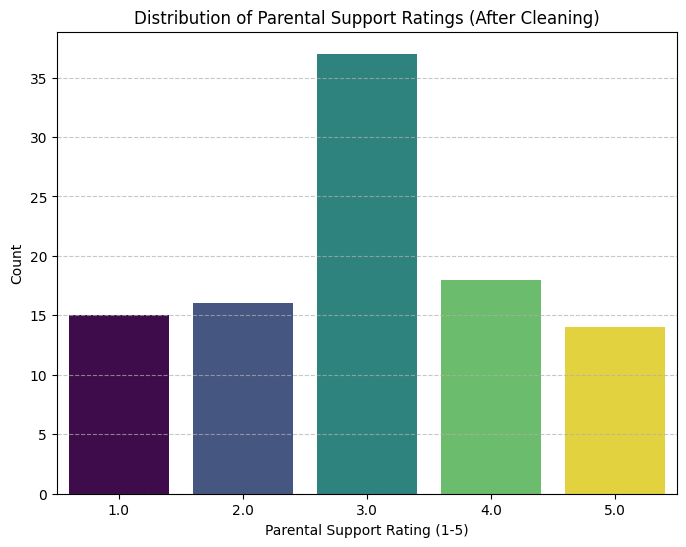

In [15]:
### Handling Missing and Inconsistent Data in 'Parental_Support'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 0.0 to NaN (as it's an inconsistent value outside the 1-5 range)
df ['Parental_Support'] = df ['Parental_Support'].replace(0.0, np.nan)

# Calculate the mode for 'Parental_Support'
parental_support_mode = df [ 'Parental_Support'].mode()[0]

# Impute missing values with the mode (addressing FutureWarning by not using inplace=True)
df['Parental_Support'] = df ['Parental_Support'].fillna (parental_support_mode)

print(f"Missing values in 'Parental_Support' after imputation: {df ['Parental_Support'].isnull().sum()}")
print(f"Unique values and their counts in 'Parental_Support' after cleaning:")
print(df['Parental_Support'].value_counts().sort_index())

# Update the plot to avoid FutureWarning
plt.figure(figsize=(8, 6))
sns.countplot(x='Parental_Support', data=df, hue='Parental_Support', palette='viridis', legend=False)
plt.title('Distribution of Parental Support Ratings (After Cleaning)')
plt.xlabel('Parental Support Rating (1-5)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.20,
    stratify=y,
    random_state=1
)

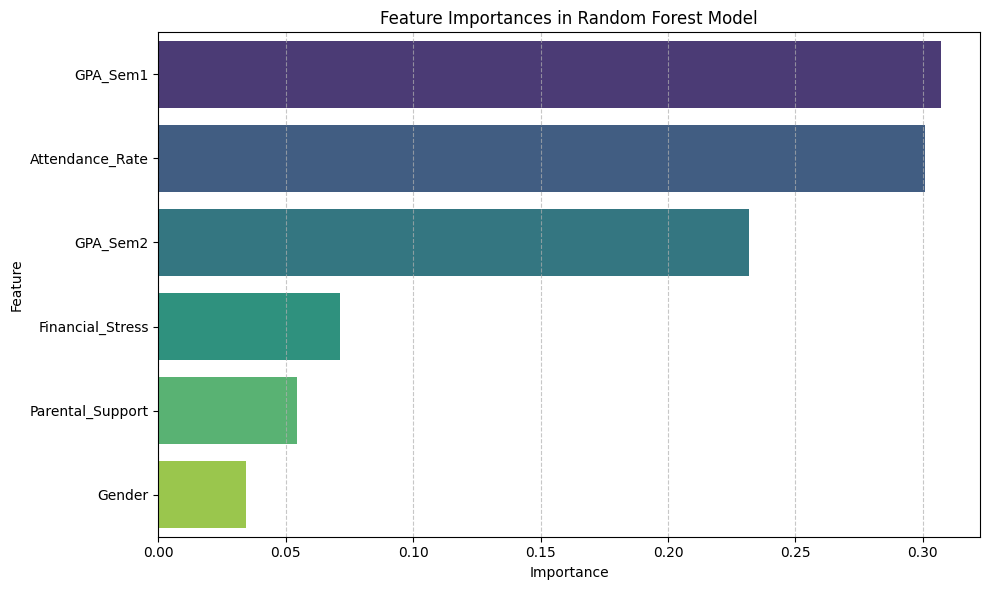

Top 5 most important features:
            Feature  Importance
2          GPA_Sem1    0.307090
4   Attendance_Rate    0.300670
3          GPA_Sem2    0.231879
5  Financial_Stress    0.071317
1  Parental_Support    0.054515


In [17]:
feature_importance = model.feature_importances_

features_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': feature_importance
})

features_df = features_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df, hue='Feature', palette='viridis')
plt.title('Feature Importances in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(features_df.head())